In [1]:
# Cell 1 — imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Cell 2 — load and audit
df = pd.read_csv(r"C:\Users\waghs.DESKTOP-OFO3QK6\churn-prediction-analysis\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
print(df['Churn'].value_counts())
print(f"Churn rate: {df['Churn'].eq('Yes').mean()*100:.1f}%")
df.head()

(7043, 21)
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn rate: 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Cell 3 — fix TotalCharges (it loads as string)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

         Contract  churn_rate
0  Month-to-month   42.709677
1        One year   11.269518
2        Two year    2.831858


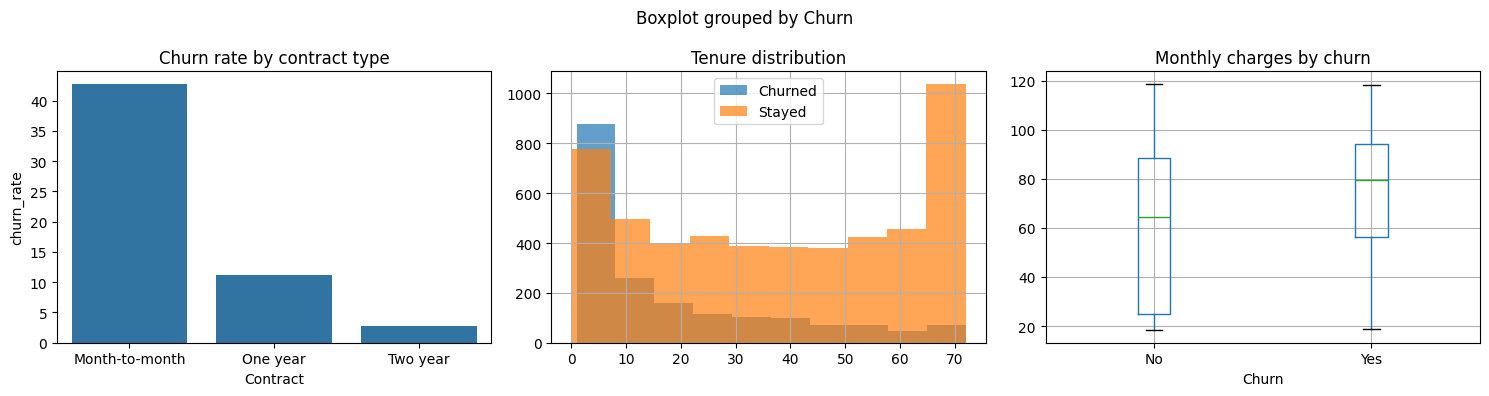

In [7]:
# Cell 4 — churn rate by contract type (key insight)
churn_by_contract = df.groupby('Contract')['Churn'].apply(
    lambda x: (x=='Yes').mean()*100).reset_index()
churn_by_contract.columns = ['Contract', 'churn_rate']
print(churn_by_contract)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Plot 1: churn by contract type
sns.barplot(data=churn_by_contract, x='Contract', y='churn_rate', ax=axes[0])
axes[0].set_title('Churn rate by contract type')
# Plot 2: tenure distribution by churn
df[df['Churn']=='Yes']['tenure'].hist(ax=axes[1], alpha=0.7, label='Churned')
df[df['Churn']=='No']['tenure'].hist(ax=axes[1], alpha=0.7, label='Stayed')
axes[1].legend(); axes[1].set_title('Tenure distribution')
# Plot 3: monthly charges by churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[2])
axes[2].set_title('Monthly charges by churn')
plt.tight_layout(); plt.show()

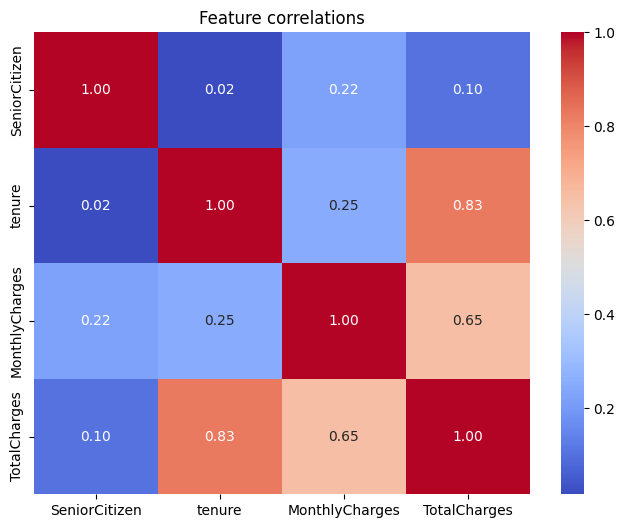

In [8]:
# Cell 5 — correlation heatmap (numeric columns only)
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature correlations'); plt.show()

In [9]:
# Cell 6 — encode and save cleaned data
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)
df_encoded = pd.get_dummies(df.drop(['customerID','Churn'], axis=1))
df_encoded['Churn'] = df['Churn_binary'].values
df_encoded.to_csv('../data/processed/customer_churn_clean.csv', index=False)
print('Saved. Shape:', df_encoded.shape)

Saved. Shape: (7043, 47)
